# RynnBrain 推論レシピ

## Section 1: 空間理解
このセクションでは、RynnBrain の空間理解能力を示します。2 つのモードをサポートしています。

1. 汎用空間理解: 指示はテキストのみです。

2. 細粒度空間理解: 指示に細粒度のバウンディングボックスが含まれます。

### [セットアップ] 可視化ユーティリティの読み込み

In [1]:
import os
ROOT_PATH="." # set the path to root dir
assert ROOT_PATH != "", "Please set ROOT_PATH to the cookbooks directory."
os.chdir(ROOT_PATH)

import glob
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPyImage
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sample_video_frames_and_show(
    video_path,
    num_samples=32,
    cols=8,
    figsize_per_cell=1.2,  
    title="index",
    downscale=2          
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Can not open video: {video_path}")

    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = np.linspace(0, n_frames - 1, num_samples).round().astype(int)

    frames = []
    valid_idxs = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame_bgr = cap.read()
        if not ok:
            continue
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

        if downscale is not None and downscale > 1:
            h, w = frame_rgb.shape[:2]
            new_size = (w // downscale, h // downscale)
            frame_rgb = cv2.resize(frame_rgb, new_size, interpolation=cv2.INTER_AREA)

        frames.append(frame_rgb)
        valid_idxs.append(idx)

    cap.release()

    cols = min(cols, len(frames)) if len(frames) > 0 else cols
    rows = int(np.ceil(len(frames) / cols)) if len(frames) > 0 else 1
    plt.figure(figsize=(cols * figsize_per_cell, rows * figsize_per_cell))

    for i, img in enumerate(frames):
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        if title == "index":
            ax.set_title(f"{i}", fontsize=8)
        elif title == "frame_idx":
            ax.set_title(f"{valid_idxs[i]}", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def add_frame_id(conversation):
  for message in conversation:
    if message["role"] == "user":
        image_idx = 0
        new_contents = []
        for i, content in enumerate(message["content"]):
            if content["type"] == "image":
                    new_contents.append({"type": "text", "text": f"<frame {image_idx}>: "})
                    image_idx += 1
            new_contents.append(content)
        message["content"] = new_contents
  return conversation


def show_images_grid(
    img_dir,
    n=8,
    cols=4,
    figsize_per_cell=(4, 4),
    exts=("png", "jpg", "jpeg", "bmp", "webp"),
    sort=True,
    show_title=True,
    keep_axis=True,
):
    patterns = [os.path.join(img_dir, f"*.{e}") for e in exts]
    paths = []
    for pat in patterns:
        paths.extend(glob.glob(pat))
    if sort:
        paths = sorted(paths)

    paths = paths[:n]
    if len(paths) == 0:
        raise FileNotFoundError(f"No images found in {img_dir} with extensions {exts}")

    rows = (len(paths) + cols - 1) // cols
    fig_w = figsize_per_cell[0] * cols
    fig_h = figsize_per_cell[1] * rows
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h), squeeze=False)

    for i, ax in enumerate(axes.flat):
        if i < len(paths):
            p = paths[i]
            img = Image.open(p)
            ax.imshow(img)

            if show_title:
                ax.set_title(os.path.basename(p), fontsize=10)

            if keep_axis:
                # ax.set_xlabel("x (px)")
                # ax.set_ylabel("y (px)")
                ax.tick_params(labelsize=8)
            else:
                ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

def convert_bbox(bbox, w, h):
    x1, y1, x2, y2 = bbox
    bbox_norm = [
        int(round(x1 / (w-1) * 1000)),
        int(round(y1 / (h-1) * 1000)),
        int(round(x2 / (w-1) * 1000)),
        int(round(y2 / (h-1) * 1000)),
    ]
    bbox_norm = [max(0, min(1000, v)) for v in bbox_norm]
    return f"({bbox_norm[0]}, {bbox_norm[1]}), ({bbox_norm[2]}, {bbox_norm[3]})"

def draw_bbox_on_image(img_path, bbox, color="red", width=4, show_width=200):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    x1, y1, x2, y2 = bbox
    draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
    img.thumbnail((show_width, show_width)) 
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    display(IPyImage(data=buf.getvalue(), width=show_width))

### [共通] モデルとプロセッサの読み込み

In [2]:
from transformers import AutoModelForImageTextToText, AutoProcessor

model_path = "Alibaba-DAMO-Academy/RynnBrain-8B"
model = AutoModelForImageTextToText.from_pretrained(model_path, dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained(model_path)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

### 例 1: 汎用空間理解

1. 動画を読み込み、可視化する

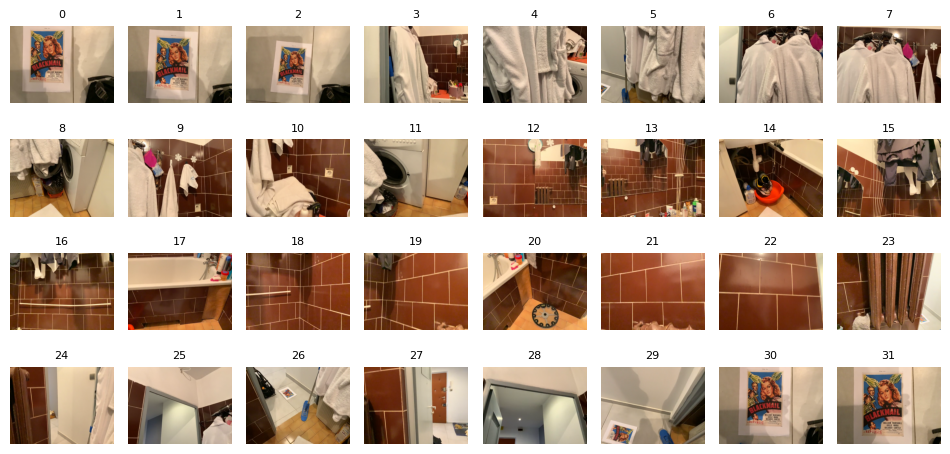

In [3]:
VIDEO_PATH = './assets/spatial_understanding/47334372.mp4'
sample_video_frames_and_show(VIDEO_PATH)

2. メッセージを生成し、RynnBrain で推論する

In [4]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "video",
                "video": VIDEO_PATH,
            },
            {"type": "text", "text": "Measuring from the closest point of each object, what is the distance between the washer and the bathtub (in meters)?"},
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0]
print(output_text)

/home/lm/git/RynnBrain/.venv/lib/python3.12/site-packages/transformers/video_processing_utils.py:879: UserWarning: `torchcodec` is not installed and cannot be used to decode the video by default. Falling back to `torchvision`. Note that `torchvision` decoding is deprecated and will be removed in future versions. 
  warnings.warn(
/home/lm/git/RynnBrain/.venv/lib/python3.12/site-packages/transformers/video_utils.py:524: UserWarning: Using `torchvision` for video decoding is deprecated and will be removed in future versions. Please use `torchcodec` instead.
  warnings.warn(
/home/lm/git/RynnBrain/.venv/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.

ImportError: PyAV is not installed, and is necessary for the video operations in torchvision.
See https://github.com/mikeboers/PyAV#installation for instructions on how to
install PyAV on your system.


### 例 2: 細粒度空間理解

1. 動画を読み込み、可視化する

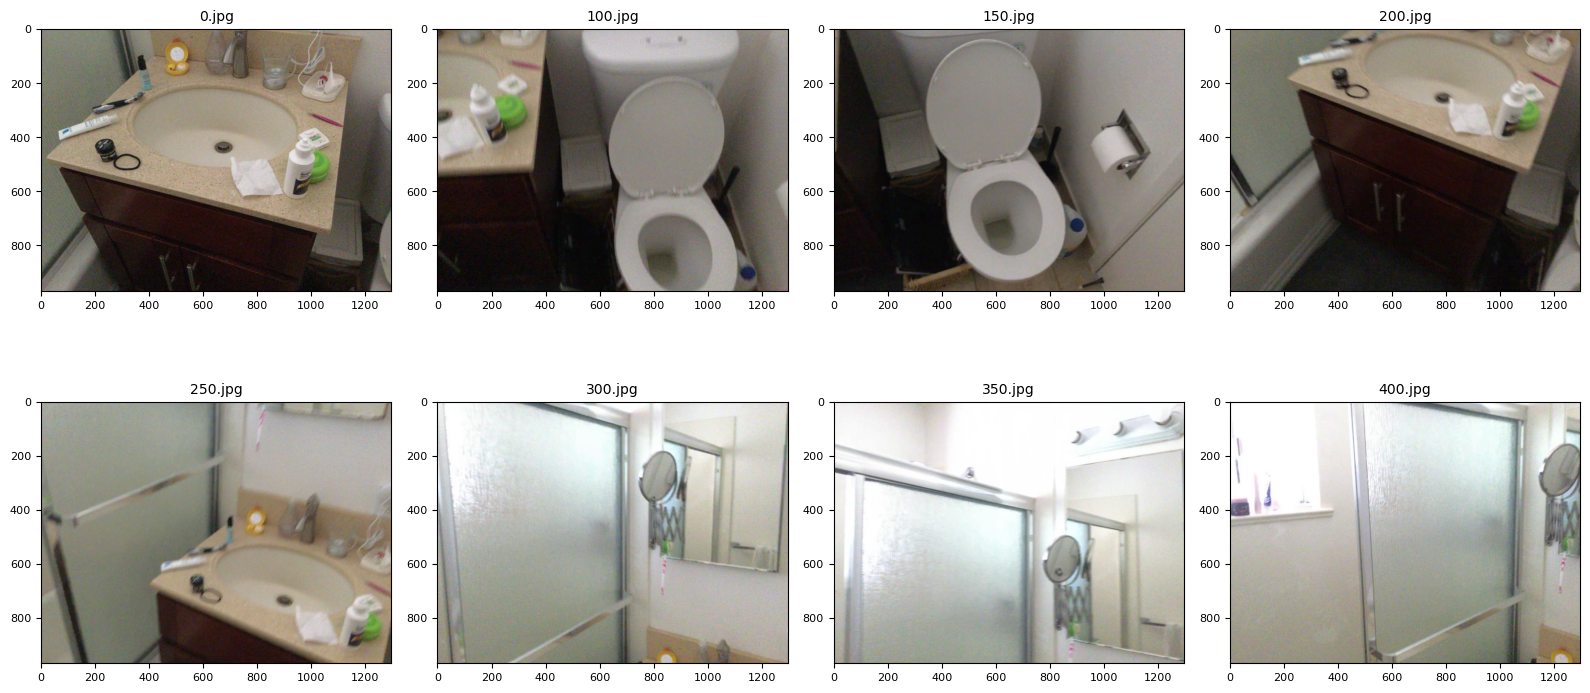

In [8]:
VIDEO_PATH="assets/spatial_understanding/0"
show_images_grid(VIDEO_PATH)

2. bbox を選択し、メッセージを生成する

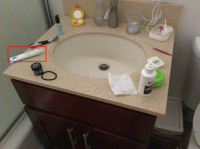

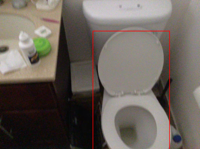

[{'role': 'user', 'content': [{'type': 'text', 'text': '<frame 0>: '}, {'type': 'image', 'image': 'assets/spatial_understanding/0/0.jpg'}, {'type': 'text', 'text': '<frame 1>: '}, {'type': 'image', 'image': 'assets/spatial_understanding/0/50.jpg'}, {'type': 'text', 'text': '<frame 2>: '}, {'type': 'image', 'image': 'assets/spatial_understanding/0/100.jpg'}, {'type': 'text', 'text': '<frame 3>: '}, {'type': 'image', 'image': 'assets/spatial_understanding/0/150.jpg'}, {'type': 'text', 'text': '<frame 4>: '}, {'type': 'image', 'image': 'assets/spatial_understanding/0/200.jpg'}, {'type': 'text', 'text': '<frame 5>: '}, {'type': 'image', 'image': 'assets/spatial_understanding/0/250.jpg'}, {'type': 'text', 'text': '<frame 6>: '}, {'type': 'image', 'image': 'assets/spatial_understanding/0/300.jpg'}, {'type': 'text', 'text': '<frame 7>: '}, {'type': 'image', 'image': 'assets/spatial_understanding/0/350.jpg'}, {'type': 'text', 'text': '<frame 8>: '}, {'type': 'image', 'image': 'assets/spatial_u

In [10]:
from pathlib import Path

exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def numeric_key(path):
    name = os.path.splitext(os.path.basename(path))[0]
    if name.isdigit():
        return int(name)
    import re
    m = re.search(r'\d+', name)
    return int(m.group()) if m else name

img_paths = sorted(
    [
        os.path.join(VIDEO_PATH, f)
        for f in os.listdir(VIDEO_PATH)
        if os.path.splitext(f)[1].lower() in exts
    ],
    key=numeric_key
)

content = []
for p in img_paths:
    content.append({"type": "image", "image": str(p)})

w, h = Image.open(img_paths[0]).size
# object0
bbox_raw_0 = [50, 300, 300, 400]
frame_idx_0 = 0
draw_bbox_on_image(img_paths[frame_idx_0], bbox_raw_0)
bbox_str_0 = convert_bbox(bbox_raw_0, w, h)
# object1
bbox_raw_1 = [600, 200, 1100, 1000]
frame_idx_1 = 2
draw_bbox_on_image(img_paths[frame_idx_1], bbox_raw_1)
bbox_str_1 = convert_bbox(bbox_raw_1, w, h)

content.append({"type": "text", "text": f"What is the distance between <object> <frame{frame_idx_0}>; {bbox_str_0} </object> and <object> <frame{frame_idx_1}>; {bbox_str_1} </object>?"})

messages = [
    {
        "role": "user",
        "content": content
    }
]
messages = add_frame_id(messages)
print(messages)

3. RynnBrain で推論する

In [11]:
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0]
print(output_text)

1.02 meters
